### Plots


In [110]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline


In [206]:
def root_directory():
    """
    Gets the current working directory
    within which the base directory will be created
    """
    root = os.getcwd()
    return root

def create_base_directory(geometry):
    """
    This is the base directory for a given grain geometry
    where anything else will be saved in
    """
    root = root_directory()
    geometry_dir = os.path.join(root, geometry)
    if not os.path.isdir(geometry_dir):
        os.mkdir(geometry_dir)
    return geometry_dir

def base_directory(geometry):
    """
    This is the base directory for a given grain geometry
    where anything else will be saved in
    """
    root = root_directory()
    geometry_dir = os.path.join(root, geometry)
    #if not os.path.isdir(geometry_dir):
        #os.mkdir(geometry_dir)
    return geometry_dir

def collect_energylog_info(elongation, size, t_prop, tt_prop, easy_axis):
    size_df = [['size (nm)', 'tt_prop (%)', 'global N-eval', 'N-eval',
                'E-anis', 'E-stress', 'E-exch1', 'E-exch2','E-exch3',
                'E-exch4', 'E-ext', 'E-demag', 'E-tot', 'Mx','My','Mz']]
    
    for n in range(len(tt_prop)):
        energylog_dir = os.path.join(base,
                             'taenite{}_tetrataenite{}'.format(t_prop[n],tt_prop[n]),
                             'E{}'.format(elongation),
                             'energylog',
                             'groundstates')
        
        for file in os.listdir(energylog_dir):
            grain_size = int(file.split('_')[0])
            if grain_size == size and easy_axis in file:
                filepath = os.path.join(energylog_dir, file)
                with open(filepath, 'r') as f:
                    content = f.readlines()
                ll = list(filter(None, content[-1].strip().split(' ')))
                ll = np.array(ll, dtype = float)
                ll_ = [size, tt_prop[n]]
                for l in ll:
                    ll_.append(l)
                size_df.append(ll_)
                #print(ll)
                #print(len(ll))
            #break
    df = pd.DataFrame(size_df)
    df.columns = df.iloc[0]
    df = df[1:]
    df
    
    return df

def chunking_data_frame(data_frame, tt_prop):
    averaged_values = [['size (nm)', 'tt_prop (%)', 'mean_E-anis', 'std_E-anis',
                        'mean_E-exch1', 'std_E-exch1','mean_E-exch2', 'std_E-exch2',
                        'mean_E-demag','std_E-demag', 'mean_E-tot', 'std_E-tot']]
    
    list_df = np.array_split(data_frame, len(tt_prop))
    
    for df in list_df:
        size = df['size (nm)'].mean()
        tt_prop = df['tt_prop (%)'].mean()
        # anisotropy energy
        mean_E_anis = df['E-anis'].mean()
        std_E_anis = df['E-anis'].std()
        # exchange 1 energy
        mean_E_exch1 = df['E-exch1'].mean()
        std_E_exch1 = df['E-exch1'].std()
        # exchange 2 energy
        mean_E_exch2 = df['E-exch2'].mean()
        std_E_exch2 = df['E-exch2'].std()
        # demagnetizing energy
        mean_E_demag = df['E-demag'].mean()
        std_E_demag = df['E-demag'].std()
        # total energy
        mean_E_tot = df['E-tot'].mean()
        std_E_tot = df['E-tot'].std()
        # wrapping up
        results = [size, tt_prop, mean_E_anis, std_E_anis,
                   mean_E_exch1, std_E_exch1, mean_E_exch2,
                   std_E_exch2, mean_E_demag, std_E_demag,
                   mean_E_tot, std_E_tot]
        
        averaged_values.append(results)
    
    data_frame = pd.DataFrame(averaged_values)
    data_frame.columns = data_frame.iloc[0]
    data_frame = data_frame[1:]
    
    return data_frame      
    

### Easy axis 1 (i.e., 1 0 0)
* E10
* 10 nm

In [214]:
geometry = 'spheroid'
t_prop = np.arange(80,-20,-20) # percentage of taenite
tt_prop = 100 - t_prop # percentage of tetrataenite
base = base_directory(geometry)

* Elongation = 10 %

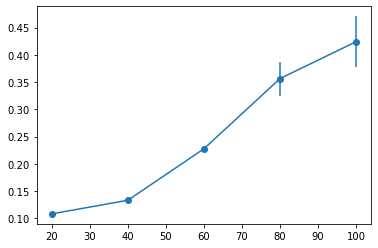

In [236]:
elongation = 10
easy_axis = 'easy1'
size_df_easy1 = collect_energylog_info(elongation, size, t_prop, tt_prop, easy_axis)
average_df_easy1 = chunking_data_frame(size_df_easy1, tt_prop)
plt.errorbar(average_df_easy1['tt_prop (%)'], average_df_easy1['mean_E-tot'], yerr = average_df_easy1['std_E-tot'], fmt = 'o-', label = '$(1 0 0)$')
#plt.title('Elongation = {} %, grain size = {} nm'.format(elongation, size))
#plt.xlabel('Degree of ordering (%)')
#plt.ylabel('Total Energy (arbitraty units)')
#plt.legend()
plt.show()

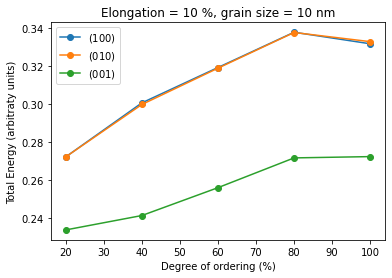

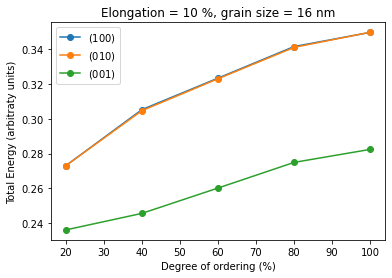

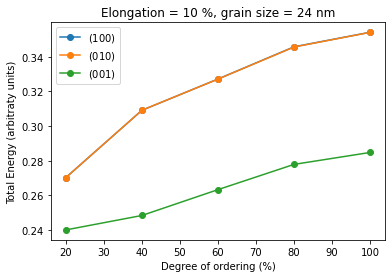

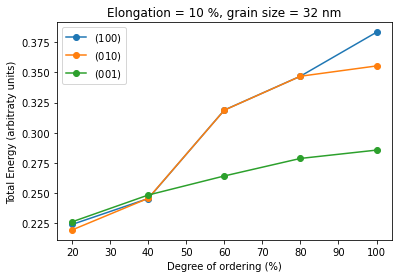

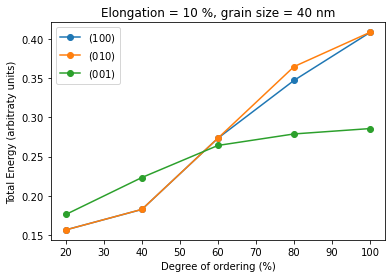

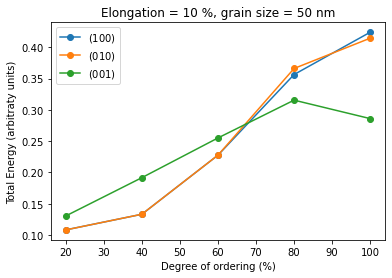

In [222]:
elongation = 10
for size in [10, 16, 24, 32, 40, 50]:

    easy_axis = 'easy1'
    size_df_easy1 = collect_energylog_info(elongation, size, t_prop, tt_prop, easy_axis)
    average_df_easy1 = chunking_data_frame(size_df_easy1, tt_prop)

    easy_axis = 'easy2'
    size_df_easy2 = collect_energylog_info(elongation, size, t_prop, tt_prop, easy_axis)
    average_df_easy2 = chunking_data_frame(size_df_easy2, tt_prop)

    easy_axis = 'easy3'
    size_df_easy3 = collect_energylog_info(elongation, size, t_prop, tt_prop, easy_axis)
    average_df_easy3 = chunking_data_frame(size_df_easy3, tt_prop)


    plt.plot(average_df_easy1['tt_prop (%)'],average_df_easy1['mean_E-tot'], 'o-', label = '$(1 0 0)$')
    plt.plot(average_df_easy2['tt_prop (%)'],average_df_easy2['mean_E-tot'],'o-', label = '$(0 1 0)$')
    plt.plot(average_df_easy3['tt_prop (%)'],average_df_easy3['mean_E-tot'],'o-', label = '$(0 0 1)$')
    plt.title('Elongation = {} %, grain size = {} nm'.format(elongation, size))
    plt.xlabel('Degree of ordering (%)')
    plt.ylabel('Total Energy (arbitraty units)')
    plt.legend()
    plt.show()

* Elongation = 30 %

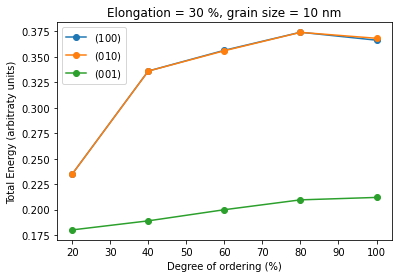

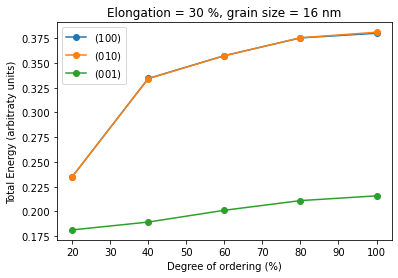

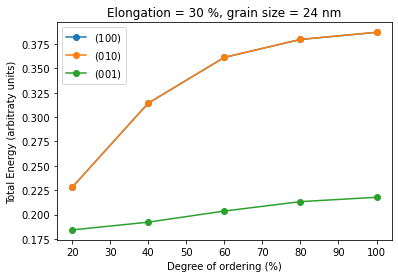

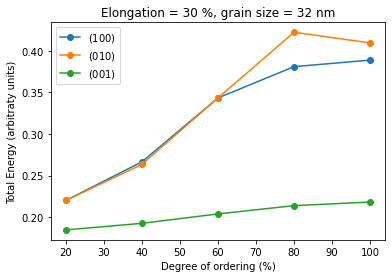

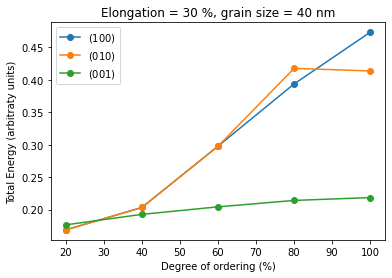

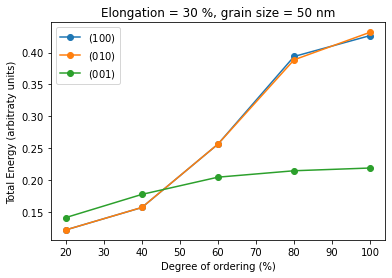

In [218]:
elongation = 30
for size in [10, 16, 24, 32, 40, 50]:

    easy_axis = 'easy1'
    size_df_easy1 = collect_energylog_info(elongation, size, t_prop, tt_prop, easy_axis)
    average_df_easy1 = chunking_data_frame(size_df_easy1, tt_prop)

    easy_axis = 'easy2'
    size_df_easy2 = collect_energylog_info(elongation, size, t_prop, tt_prop, easy_axis)
    average_df_easy2 = chunking_data_frame(size_df_easy2, tt_prop)

    easy_axis = 'easy3'
    size_df_easy3 = collect_energylog_info(elongation, size, t_prop, tt_prop, easy_axis)
    average_df_easy3 = chunking_data_frame(size_df_easy3, tt_prop)


    plt.plot(average_df_easy1['tt_prop (%)'],average_df_easy1['mean_E-tot'],'o-', label = '$(1 0 0)$')
    plt.plot(average_df_easy2['tt_prop (%)'],average_df_easy2['mean_E-tot'],'o-', label = '$(0 1 0)$')
    plt.plot(average_df_easy3['tt_prop (%)'],average_df_easy3['mean_E-tot'],'o-', label = '$(0 0 1)$')
    plt.title('Elongation = {} %, grain size = {} nm'.format(elongation, size))
    plt.xlabel('Degree of ordering (%)')
    plt.ylabel('Total Energy (arbitraty units)')
    plt.legend()
    plt.show()

* Elongation = 50 %

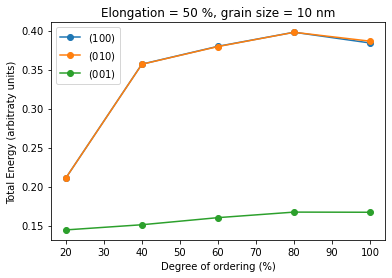

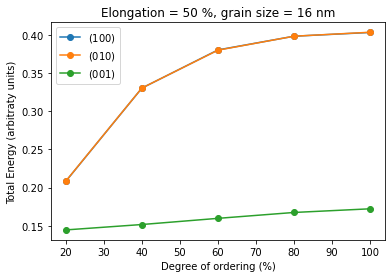

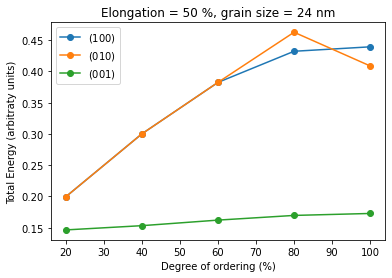

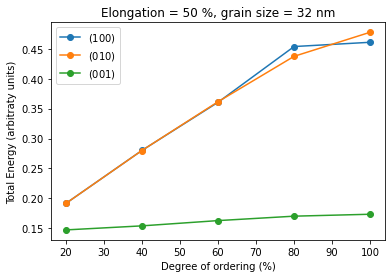

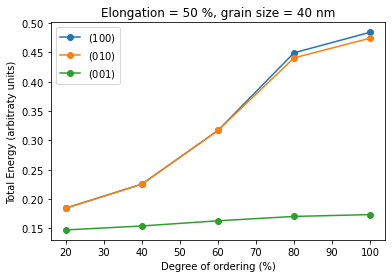

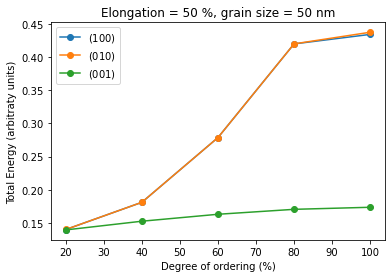

In [217]:
elongation = 50
for size in [10, 16, 24, 32, 40, 50]:

    easy_axis = 'easy1'
    size_df_easy1 = collect_energylog_info(elongation, size, t_prop, tt_prop, easy_axis)
    average_df_easy1 = chunking_data_frame(size_df_easy1, tt_prop)

    easy_axis = 'easy2'
    size_df_easy2 = collect_energylog_info(elongation, size, t_prop, tt_prop, easy_axis)
    average_df_easy2 = chunking_data_frame(size_df_easy2, tt_prop)

    easy_axis = 'easy3'
    size_df_easy3 = collect_energylog_info(elongation, size, t_prop, tt_prop, easy_axis)
    average_df_easy3 = chunking_data_frame(size_df_easy3, tt_prop)


    plt.plot(average_df_easy1['tt_prop (%)'],average_df_easy1['mean_E-tot'],'o-', label = '$(1 0 0)$')
    plt.plot(average_df_easy2['tt_prop (%)'],average_df_easy2['mean_E-tot'],'o-', label = '$(0 1 0)$')
    plt.plot(average_df_easy3['tt_prop (%)'],average_df_easy3['mean_E-tot'],'o-', label = '$(0 0 1)$')
    plt.title('Elongation = {} %, grain size = {} nm'.format(elongation, size))
    plt.xlabel('Degree of ordering (%)')
    plt.ylabel('Total Energy (arbitraty units)')
    plt.legend()
    plt.show()

In [ ]:
elongation = 10
size = 10

easy_axis = 'easy1'
size_df_easy1 = collect_energylog_info(elongation, size, t_prop, tt_prop, easy_axis)
average_df_easy1 = chunking_data_frame(size_df_easy1, tt_prop)

easy_axis = 'easy2'
size_df_easy2 = collect_energylog_info(elongation, size, t_prop, tt_prop, easy_axis)
average_df_easy2 = chunking_data_frame(size_df_easy2, tt_prop)

easy_axis = 'easy3'
size_df_easy3 = collect_energylog_info(elongation, size, t_prop, tt_prop, easy_axis)
average_df_easy3 = chunking_data_frame(size_df_easy3, tt_prop)


plt.plot(average_df_easy1['tt_prop (%)'],average_df_easy1['mean_E-tot'],'o-', label = '$(1 0 0)$')
plt.plot(average_df_easy2['tt_prop (%)'],average_df_easy2['mean_E-tot'],'o-', label = '$(0 1 0)$')
plt.plot(average_df_easy3['tt_prop (%)'],average_df_easy3['mean_E-tot'],'o-', label = '$(0 0 1)$')
plt.title('')
plt.xlabel('Degree of ordering (%)')
plt.ylabel('Total Energy (arbitraty units)')
plt.legend()
plt.show()